## Customer Churn Prediction

Customer Churn Prediction is a Machine Learning task that focuses on identifying customers who are likely to stop using a service. The goal is to analyze historical customer data and build a model that can predict churn in advance, allowing businesses to take preventive actions such as retention offers or improved customer support.

This prediction helps businesses reduce customer loss, improve satisfaction, and increase overall revenue.


### Getting Data From SQL Server

The dataset is stored in SQL Server and is retrieved directly using Python for further preprocessing and Machine Learning tasks. SQLAlchemy is used to establish the database connection and load the data into a Pandas DataFrame for analysis and model preparation.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sqlalchemy import create_engine, text

In [4]:
# Creating database connection
engine = create_engine(
    "mssql+pyodbc://localhost\\SQLEXPRESS/db_Churn"
    "?driver=ODBC+Driver+17+for+SQL+Server"
    "&trusted_connection=yes"
)

conn = engine.connect()

In [7]:
# Checking all tables available in the db_Churn
tables = pd.read_sql("SELECT TABLE_NAME FROM INFORMATION_SCHEMA.TABLES", conn)
tables

,TABLE_NAME
0,stg_Churn
1,prod_Churn
2,vw_ChurnData
3,vw_JoinData


In [9]:
df_churn = pd.read_sql("SELECT * FROM vw_ChurnData", conn)
df_join = pd.read_sql("SELECT * FROM vw_JoinData", conn)

In [ ]:
df_join.to_csv("new_joiners_data.csv", index=False)

Two tables are extracted from the SQL Server database into Pandas DataFrames:

- df_churn: This dataset will be use for training and testing the Machine Learning model. It contains historical customer data along with churn labels.
- df_new_joiners: This dataset contains newly joined customers and will be used to make predictions on which customers are likely to churn in the future.

### Data Preprocessing

* Detailed data analysis and initial preprocessing were already performed in Power BI for database management and analytical purposes.
* In this phase, preprocessing is specifically focused on preparing the dataset for Machine Learning models.

For Machine Learning, data preprocessing involves transforming raw data into a clean, structured, and model-ready format so algorithms can learn effectively. Since ML models cannot efficiently work with incomplete, inconsistent, or non-numerical data, preprocessing helps improve model accuracy, performance, and reliability.

Key preprocessing tasks include:

* Handling missing values
* Encoding categorical variables
* Feature scaling and normalization
* Removing duplicates and outliers
* Feature selection
* Train-test splitting

This step ensures the dataset is optimized for training and evaluating Machine Learning models effectively.

In [11]:
df_churn.head()

,Customer_ID,Gender,Age,Married,State,Number_of_Referrals,Tenure_in_Months,Value_Deal,Phone_Service,Multiple_Lines,...,Payment_Method,Monthly_Charge,Total_Charges,Total_Refunds,Total_Extra_Data_Charges,Total_Long_Distance_Charges,Total_Revenue,Customer_Status,Churn_Category,Churn_Reason
0,19877-DEL,Male,35,No,Delhi,7,27,None,Yes,No,...,Credit Card,65.6,593.30,0.00,0.0,381.51,974.81,Stayed,Others,Others
1,58353-MAH,Female,45,Yes,Maharashtra,14,13,None,Yes,Yes,...,Credit Card,-4.0,542.40,38.33,10.0,96.21,610.28,Stayed,Others,Others
2,25063-WES,Male,51,No,West Bengal,4,35,Deal 5,Yes,No,...,Bank Withdrawal,73.9,280.85,0.00,0.0,134.60,415.45,Churned,Competitor,Competitor had better devices
3,59787-KAR,Male,79,No,Karnataka,3,21,Deal 4,Yes,No,...,Bank Withdrawal,98.0,1237.85,0.00,0.0,361.66,1599.51,Churned,Dissatisfaction,Product dissatisfaction
4,28544-TAM,Female,80,No,Tamil Nadu,3,8,None,Yes,No,...,Credit Card,83.9,267.40,0.00,0.0,22.14,289.54,Churned,Dissatisfaction,Network reliability


**1. Checking missing values & Dtypes**

In [13]:
df_churn.info()

<class 'pandas.DataFrame'>
RangeIndex: 6007 entries, 0 to 6006
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Customer_ID                  6007 non-null   str    
 1   Gender                       6007 non-null   str    
 2   Age                          6007 non-null   int64  
 3   Married                      6007 non-null   str    
 4   State                        6007 non-null   str    
 5   Number_of_Referrals          6007 non-null   int64  
 6   Tenure_in_Months             6007 non-null   int64  
 7   Value_Deal                   6007 non-null   str    
 8   Phone_Service                6007 non-null   str    
 9   Multiple_Lines               6007 non-null   str    
 10  Internet_Service             6007 non-null   str    
 11  Internet_Type                6007 non-null   str    
 12  Online_Security              6007 non-null   str    
 13  Online_Backup                

**2. Checking Duplicates**

In [16]:
df_churn.duplicated().sum()

0

In [18]:
df_churn['Customer_ID'].duplicated().sum()

0

**3. Checking Outliers & correlation**

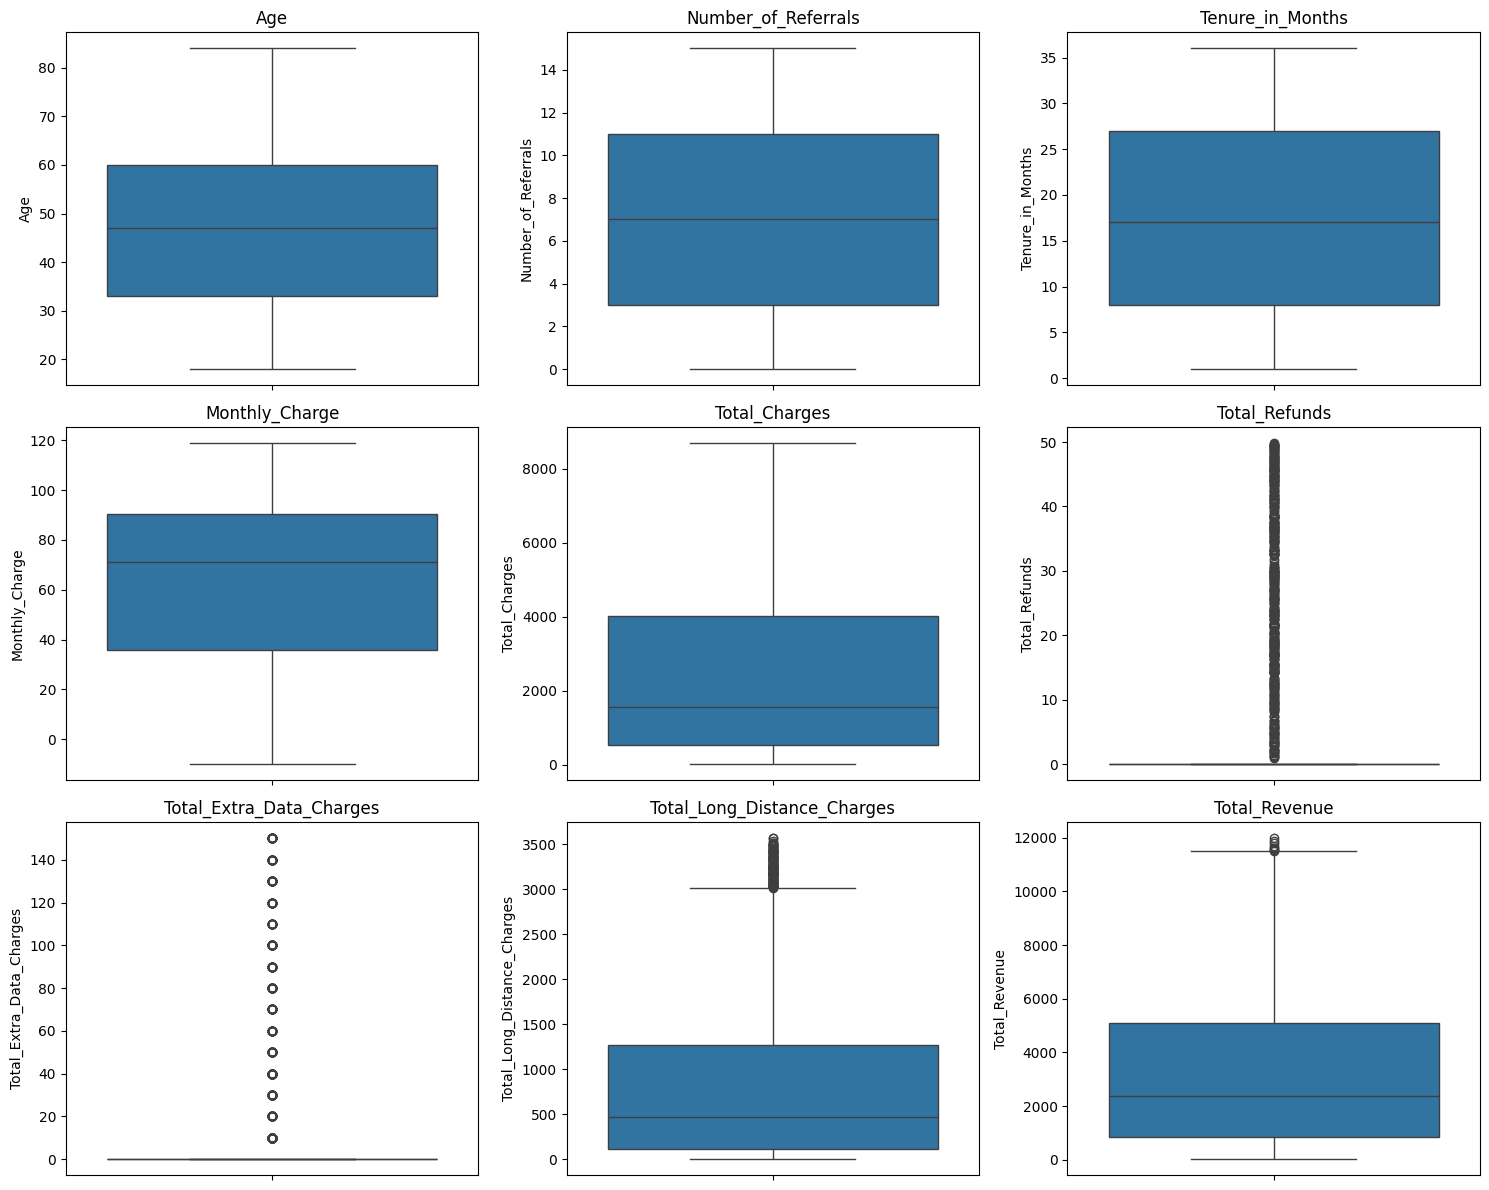

In [20]:
# Select numerical columns
num_cols = df_churn.select_dtypes(include='number').columns
n_cols = len(num_cols)

# Define grid size
cols = 3
rows = int(np.ceil(n_cols / cols)) # 9/3 = 3

plt.figure(figsize=(cols * 5, rows * 4))

for i, col in enumerate(num_cols):
    plt.subplot(rows, cols, i + 1)
    sns.boxplot(y=df_churn[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [45]:
corr = pd.concat([df_churn[num_cols], df_churn["Customer_Status"].map({"Stayed": 0, "Churned": 1})], axis=1).corr()

In [47]:
corr

,Age,Number_of_Referrals,Tenure_in_Months,Monthly_Charge,Total_Charges,Total_Refunds,Total_Extra_Data_Charges,Total_Long_Distance_Charges,Total_Revenue,Customer_Status
Age,1.000000,-0.016397,0.149522,0.125732,0.047938,0.014267,0.026735,-0.006191,0.036402,0.108174
Number_of_Referrals,-0.016397,1.000000,-0.014297,-0.013672,-0.003073,0.015018,-0.003919,0.009926,0.000454,-0.006502
Tenure_in_Months,0.149522,-0.014297,1.000000,-0.006259,-0.005597,0.010538,0.023246,0.000232,-0.004197,0.007274
Monthly_Charge,0.125732,-0.013672,-0.006259,1.000000,0.619239,0.011646,0.117952,0.205873,0.554240,0.164216
Total_Charges,0.047938,-0.003073,-0.005597,0.619239,1.000000,0.023244,0.119024,0.585534,0.970130,-0.251783
Total_Refunds,0.014267,0.015018,0.010538,0.011646,0.023244,1.000000,0.019149,0.016602,0.020768,-0.045516
Total_Extra_Data_Charges,0.026735,-0.003919,0.023246,0.117952,0.119024,0.019149,1.000000,0.050786,0.118533,0.008098
Total_Long_Distance_Charges,-0.006191,0.009926,0.000232,0.205873,0.585534,0.016602,0.050786,1.000000,0.764554,-0.273525
Total_Revenue,0.036402,0.000454,-0.004197,0.554240,0.970130,0.020768,0.118533,0.764554,1.000000,-0.281553
Customer_Status,0.108174,-0.006502,0.007274,0.164216,-0.251783,-0.045516,0.008098,-0.273525,-0.281553,1.000000


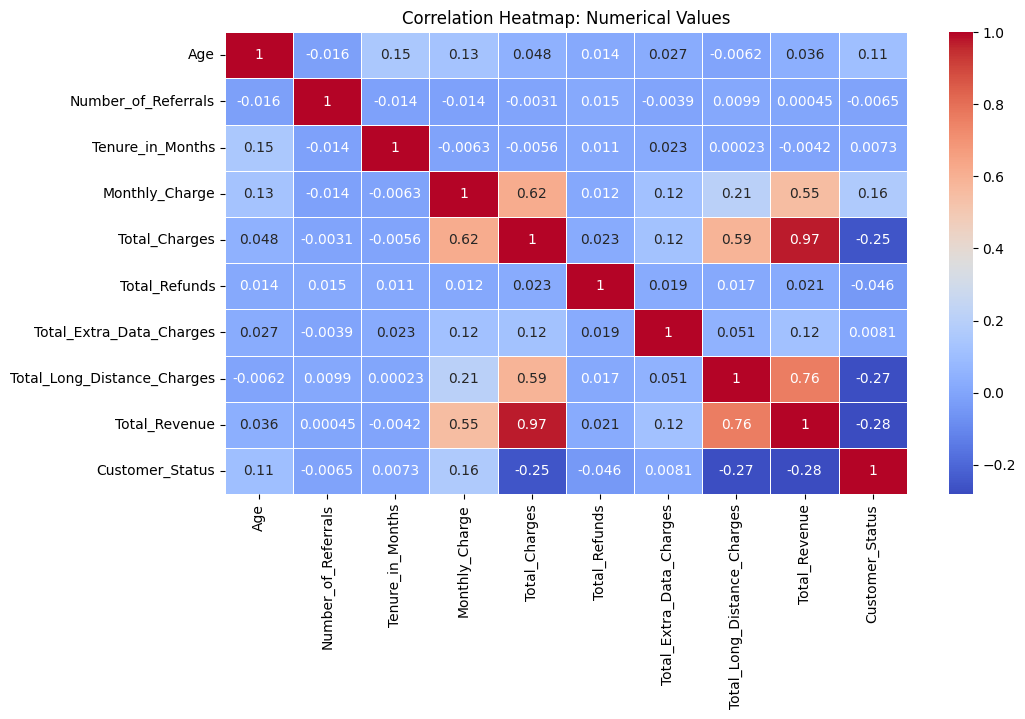

In [95]:
plt.figure(figsize=(11,6))
sns.heatmap(data=corr, annot = True, linewidths= 0.5, cmap='coolwarm')
plt.title("Correlation Heatmap: Numerical Values")
plt.show()

**4. Feature Selection**

In [143]:
# Separate  features (X) and target variable (y)
# Drop the unneeded columns immediately to prevent target leakage
columns_to_drop = ["Churn_Category", "Churn_Reason", "Customer_ID","Customer_Status"]
X = df_churn.drop(columns=columns_to_drop, errors="ignore")

# Map the Target Variable string values to binary integers (Stayed = 0, Churned = 1)
y = df_churn["Customer_Status"].map({"Stayed": 0, "Churned": 1})

**5. Train-test splitting**

In [145]:
from sklearn.model_selection import train_test_split

# Performing the Train-Test Split
# Stratifying by 'y' ensures both sets have the same proportion of churned users
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (4805, 28)
Testing set shape: (1202, 28)


**6. Encoding categorical variables**

In [147]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

# Define column groups
nominal_cols = [
    "Gender",
    "Married",
    "State",
    "Value_Deal",
    "Phone_Service",
    "Multiple_Lines",
    "Internet_Service",
    "Internet_Type",
    "Online_Security",
    "Online_Backup",
    "Device_Protection_Plan",
    "Premium_Support",
    "Streaming_TV",
    "Streaming_Movies",
    "Streaming_Music",
    "Unlimited_Data",
    "Paperless_Billing",
    "Payment_Method",
]
ordinal_cols = ["Contract"]
contract_order = [["Month-to-Month", "One Year", "Two Year"]]

# Create the ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("ord", OrdinalEncoder(categories=contract_order), ordinal_cols),
        ("nom", OneHotEncoder(handle_unknown="ignore", sparse_output=False), nominal_cols),
    ],
    remainder="passthrough",  # Keeps any remaining numerical columns untouched
)

# Configure the transformer to output clean Pandas DataFrames instead of NumPy arrays
preprocessor.set_output(transform="pandas")

# 4. Fit and Transform safely
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

### Predictive Modeling & Model Selection

--- MODEL PERFORMANCE EVALUATION ---

================ Random Forest ================
Accuracy  : 0.8378
Precision : 0.7123
Recall    : 0.7349
F1-Score  : 0.7234

================ XGBoost ================
Accuracy  : 0.8386
Precision : 0.7131
Recall    : 0.7378
F1-Score  : 0.7252

================ LightGBM ================
Accuracy  : 0.8228
Precision : 0.6642
Recall    : 0.7810
F1-Score  : 0.7179



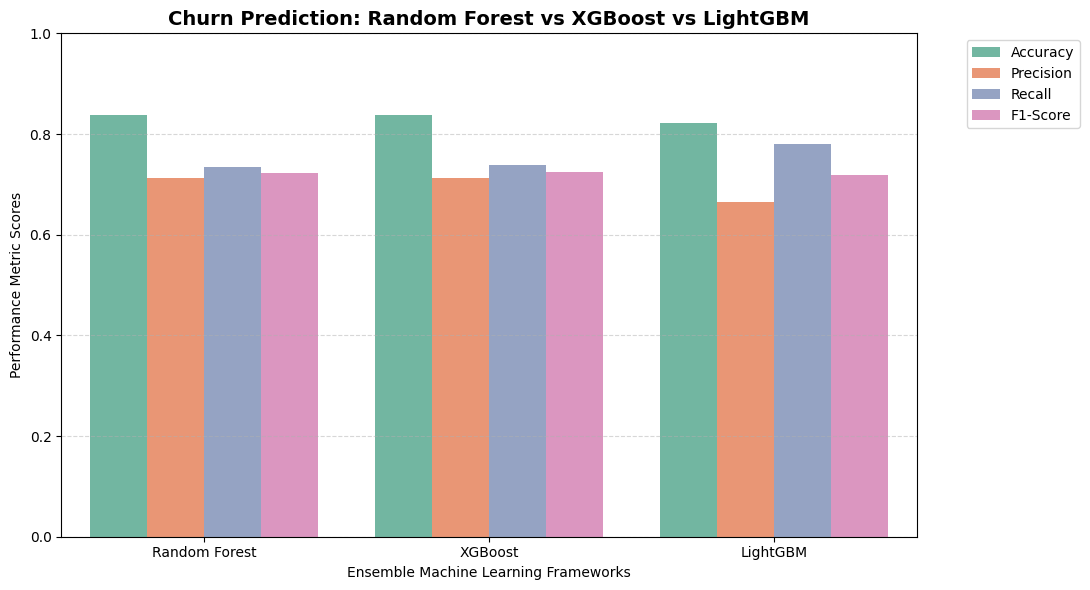

In [149]:
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from xgboost import XGBClassifier

# 1. Initialize the specific tree-based models
models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=150, max_depth=10, random_state=42, class_weight="balanced"
    ),
    "XGBoost": XGBClassifier(
        n_estimators=150,
        learning_rate=0.08,
        max_depth=5,
        random_state=42,
        scale_pos_weight=2,
        eval_metric="logloss",
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=150,
        learning_rate=0.08,
        max_depth=5,
        random_state=42,
        is_unbalance=True,  # Built-in handling for class imbalance
        verbose=-1,  # Suppress internal configuration warnings
    ),
}

# 2. Storage container for performance evaluation metrics
performance_metrics = []

# 3. Training and evaluation loop
print("--- MODEL PERFORMANCE EVALUATION ---\n")
for name, model in models.items():
    # Fit model on the processed training space
    model.fit(X_train_processed, y_train)

    # Generate predictions on test data
    y_pred = model.predict(X_test_processed)

    # Calculate operational metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # Append metrics to final dataframe tracker
    performance_metrics.append(
        {
            "Model": name,
            "Accuracy": acc,
            "Precision": prec,
            "Recall": rec,
            "F1-Score": f1,
        }
    )

    # Print clean terminal report
    print(f"================ {name} ================")
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1-Score  : {f1:.4f}\n")

# 4. Transform collected metrics into a visualization DataFrame
metrics_df = pd.DataFrame(performance_metrics)
metrics_melted = pd.melt(
    metrics_df, id_vars="Model", var_name="Metric", value_name="Score"
)

# 5. Comparative visualization output
plt.figure(figsize=(11, 6))
sns.barplot(
    data=metrics_melted, x="Model", y="Score", hue="Metric", palette="Set2"
)
plt.title(
    "Churn Prediction: Random Forest vs XGBoost vs LightGBM",
    fontsize=14,
    fontweight="bold",
)
plt.ylim(0, 1.0)
plt.ylabel("Performance Metric Scores")
plt.xlabel("Ensemble Machine Learning Frameworks")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

### Final Model Selection & Business Strategy

While hyperparameter tuning can push overall accuracy to **86.00%**, the **Baseline XGBoost Model** was deliberately chosen for deployment. 

* **The Justification:** The baseline model achieves a superior **Recall of 73.78%** on the Churn class compared to the tuned model's **65.00%**. 
* **Business Impact:** In customer retention, capturing roughly **10% more actual churners** outweighs a 2% gain in overall accuracy. This focus on high recall ensures fewer at-risk customers slip through the cracks undetected.

In [170]:
import joblib

# 1. Baseline XGBoost model
final_model = models["XGBoost"]

# 2. Save the fitted preprocessor pipeline
joblib.dump(preprocessor, "churn_preprocessor.joblib")
print("Successfully saved: churn_preprocessor.joblib")

# 3. Save the trained baseline XGBoost model
joblib.dump(final_model, "baseline_xgb_model.joblib")
print("Successfully saved: baseline_xgb_model.joblib")

Successfully saved: churn_preprocessor.joblib
Successfully saved: baseline_xgb_model.joblib


### Final Dataset Export for Dashboard Integration

1. Making predictions on a newly joined customers dataset
2. Filtering High-Risk Churn Profiles (Probability > 50%)
3. Serialization to CSV for PowerBI Dashboard

In [181]:
import joblib
import pandas as pd

# 1. Load saved production pipeline components
loaded_preprocessor = joblib.load("churn_preprocessor.joblib")
loaded_model = joblib.load("baseline_xgb_model.joblib")

# 2. Extract features 
columns_to_drop = [
    "Customer_ID",
    "Churn_Category",
    "Churn_Reason",
    "Customer_Status",
]
X_new = df_join.drop(columns=columns_to_drop, errors="ignore")

# 3. Transform the raw features using fitted transformer pipeline
X_new_processed = loaded_preprocessor.transform(X_new)

# 4. Generate the predictions and probabilities
df_join["Churn_Prediction"] = loaded_model.predict(X_new_processed)
df_join["Churn_Probability"] = loaded_model.predict_proba(X_new_processed)[:, 1]

# 5. Display the top at-risk customers sorted by highest probability
high_risk_customers = df_join[df_join["Churn_Prediction"] == 1].sort_values(
    by="Churn_Probability", ascending=False
)

print(f"Found {len(high_risk_customers)} customers at risk of churning.")
high_risk_customers.head()

Found 388 customers at risk of churning.


,Customer_ID,Gender,Age,Married,State,Number_of_Referrals,Tenure_in_Months,Value_Deal,Phone_Service,Multiple_Lines,Internet_Service,Internet_Type,Online_Security,Online_Backup,Device_Protection_Plan,Premium_Support,Streaming_TV,Streaming_Movies,Streaming_Music,Unlimited_Data,Contract,Paperless_Billing,Payment_Method,Monthly_Charge,Total_Charges,Total_Refunds,Total_Extra_Data_Charges,Total_Long_Distance_Charges,Total_Revenue,Customer_Status,Churn_Category,Churn_Reason,Churn_Prediction,Churn_Probability
100,86362-ASS,Female,35,Yes,Assam,15,11,None,Yes,No,Yes,Fiber Optic,No,No,No,Yes,No,No,No,Yes,Month-to-Month,Yes,Mailed Check,74.30,74.30,0.0,0.0,39.55,113.85,Joined,Others,Others,1,0.999499
198,86970-KER,Male,57,Yes,Kerala,2,9,None,Yes,No,Yes,DSL,No,Yes,No,No,No,No,No,No,Month-to-Month,No,Bank Withdrawal,49.50,49.50,0.0,30.0,16.99,96.49,Joined,Others,Others,1,0.999164
357,52641-JHA,Female,44,Yes,Jharkhand,7,29,None,Yes,No,Yes,Fiber Optic,No,No,No,No,No,No,No,Yes,Month-to-Month,No,Mailed Check,71.10,71.10,0.0,0.0,37.51,108.61,Joined,Others,Others,1,0.999152
252,55043-UTT,Male,43,Yes,Uttar Pradesh,8,17,None,Yes,No,Yes,Fiber Optic,No,No,No,No,No,No,No,No,Month-to-Month,Yes,Bank Withdrawal,69.90,69.90,0.0,10.0,9.36,89.26,Joined,Others,Others,1,0.999139
395,28782-PUN,Male,58,Yes,Punjab,8,7,Deal 5,Yes,No,Yes,DSL,No,No,No,No,No,No,No,Yes,Month-to-Month,Yes,Mailed Check,44.95,44.95,0.0,0.0,13.63,58.58,Joined,Others,Others,1,0.999059


In [199]:
high_risk_customers.to_csv("high_risk_churn_list.csv", index=False)